# Milestone 1: Data Pipeline - Data Perception & Preparation

## Task B1: Data Perception & Preparation [10 Marks]

This notebook implements the data pipeline for the Small Business Intelligence Analyst system.

### Objectives:
- Acquire datasets (customer reviews, social media posts, market data)
- Clean and preprocess unstructured text data
- Transform raw data into standardized format for cognitive processing
- Prepare data for sentiment analysis and topic modeling


In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Web scraping libraries
import requests
from bs4 import BeautifulSoup
import time

# Download NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
except:
    pass

# Import custom data collector
import sys
sys.path.append('../../')
from src.utils.data_collector import DataCollector

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Data Acquisition

Load datasets representing customer reviews and social media posts relevant to small businesses in Kampala.


In [10]:
# NOTE: This cell will be populated after data collection in Cell 4
# The dataset will be saved to data/raw/collected_reviews.csv
pass


In [11]:
# Data Collection: Generate 5000 synthetic reviews + attempt web scraping
# Initialize data collector
collector = DataCollector()

# Collect data from all sources
# This will:
# 1. Generate 5000 diverse synthetic reviews
# 2. Attempt to scrape real reviews from Reddit (if available)
# 3. Merge everything into one DataFrame
df_reviews = collector.collect_all_data(
    n_synthetic=5000,      # Generate 5000 synthetic reviews
    try_reddit=True,        # Attempt to scrape Reddit
    reddit_limit=200        # Try to get up to 200 Reddit posts
)

print(f"\n✅ Final reviews dataset shape: {df_reviews.shape}")
print(f"\nFirst few reviews:")
df_reviews.head(7)

# Save raw dataset to data/raw directory
import os
os.makedirs('../../data/raw', exist_ok=True)
raw_data_path = '../../data/raw/collected_reviews.csv'
df_reviews.to_csv(raw_data_path, index=False)
print(f"\n💾 Raw dataset saved to: {os.path.abspath(raw_data_path)}")
print(f"   Total reviews saved: {len(df_reviews)}")
print(f"   File size: {os.path.getsize(raw_data_path) / 1024:.2f} KB")


Starting Data Collection
Generating 5000 synthetic reviews...
✅ Generated 5000 synthetic reviews
✅ Synthetic data: 5000 reviews
Attempting to scrape reviews from Reddit (r/reviews)...
✅ Scraped 100 reviews from Reddit
✅ Reddit data: 100 reviews

Merging all data sources...
✅ Merged dataset: 5100 total reviews

Data Collection Summary
Total reviews: 5100

Source distribution:
source
Instagram    879
Facebook     861
Website      839
Google       828
Twitter      802
WhatsApp     791
Reddit       100
Name: count, dtype: int64

Location distribution:
location
Lubaga      527
Kampala     522
Kawempe     521
Muyenga     515
Central     508
Ntinda      503
Kololo      499
Bukoto      484
Makindye    466
Nakawa      455
Online      100
Name: count, dtype: int64

Sentiment distribution:
sentiment_label
positive    3000
neutral     1250
negative     750
unknown      100
Name: count, dtype: int64

✅ Final reviews dataset shape: (5100, 6)

First few reviews:

💾 Raw dataset saved to: d:\Cognitive 

In [12]:
### checking for the shape of the dataset  
df_reviews.shape 

(5100, 6)

In [13]:
# checking for the data info
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        5100 non-null   int64 
 1   text             5100 non-null   object
 2   date             5100 non-null   object
 3   source           5100 non-null   object
 4   location         5100 non-null   object
 5   sentiment_label  5100 non-null   object
dtypes: int64(1), object(5)
memory usage: 239.2+ KB


In [14]:
# checking for null values in the dataset
df_reviews.isnull().sum()

review_id          0
text               0
date               0
source             0
location           0
sentiment_label    0
dtype: int64

## Step 2: Text Preprocessing

Implement comprehensive text cleaning and preprocessing pipeline.


In [18]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Generating wordcloud of raw reviews...


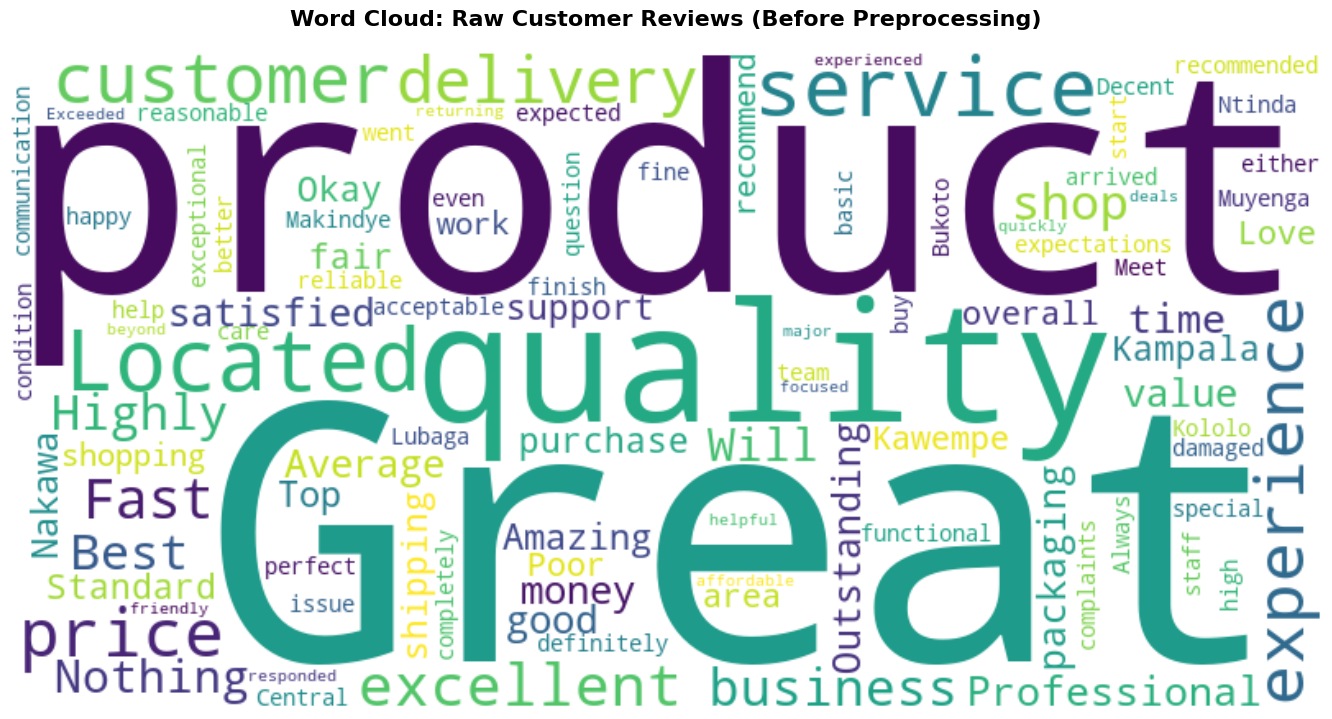


Preprocessing reviews...
Preprocessing completed!

Sample before and after preprocessing:

Generating wordcloud of cleaned reviews...


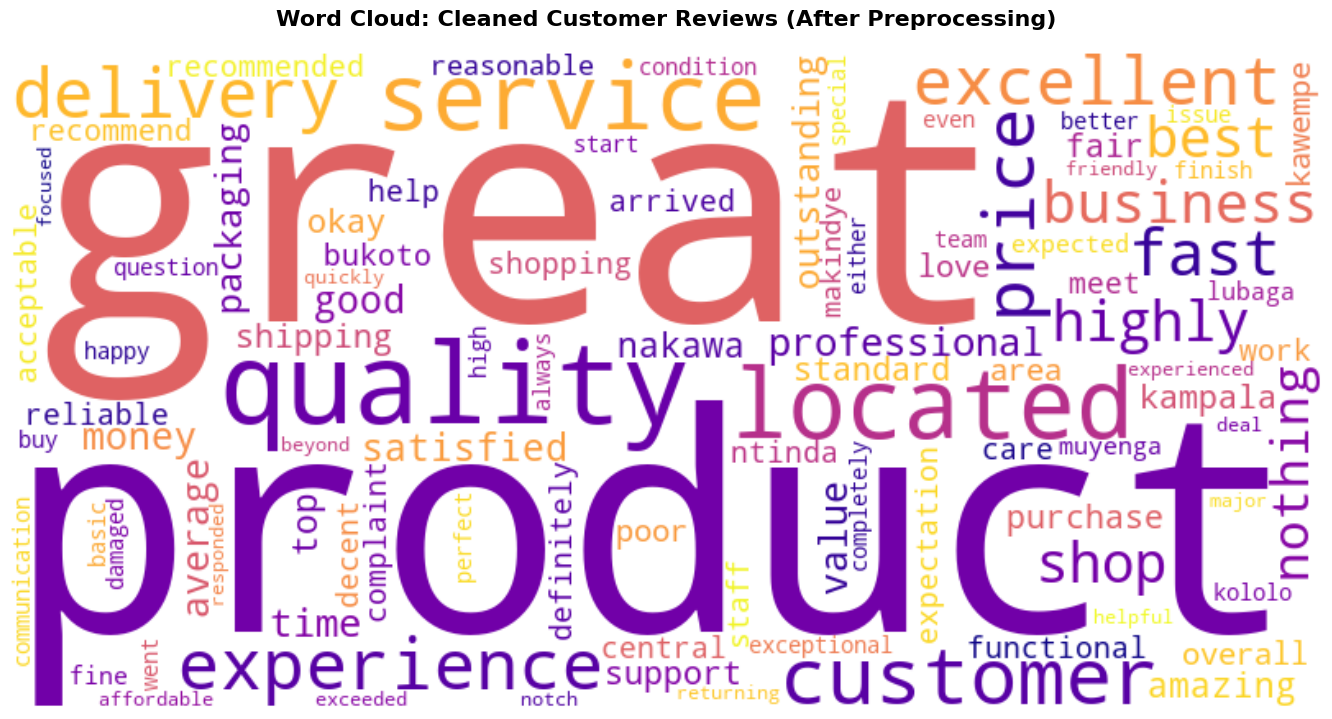


Comparing wordclouds before and after preprocessing...


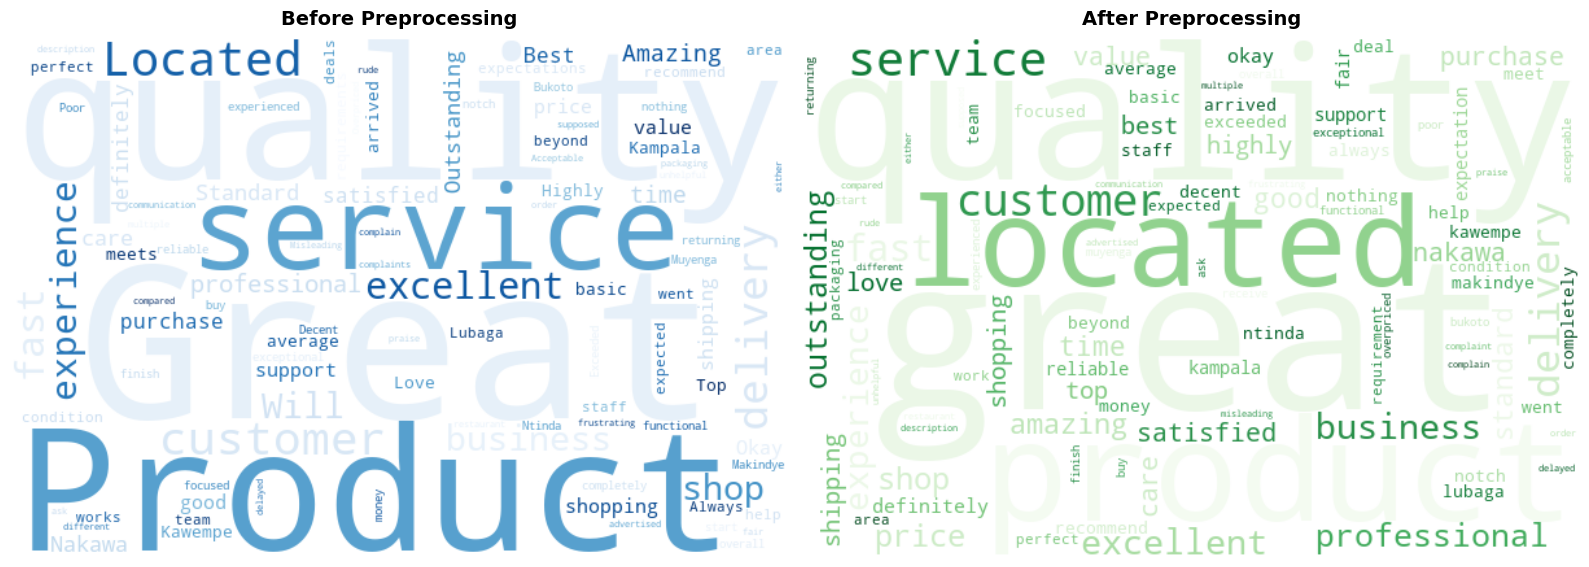

In [19]:
# Import our custom preprocessor and wordcloud generator
import sys
sys.path.append('../../')
from src.utils.text_preprocessor import TextPreprocessor
from src.utils.wordcloud_generator import WordCloudGenerator

# Initialize preprocessor and wordcloud generator
preprocessor = TextPreprocessor()
wordcloud_gen = WordCloudGenerator()

# Generate wordcloud of raw text (before preprocessing)
print("Generating wordcloud of raw reviews...")
all_raw_text = ' '.join(df_reviews['text'].dropna().astype(str))
wordcloud_gen.generate_wordcloud(
    all_raw_text, 
    title="Word Cloud: Raw Customer Reviews (Before Preprocessing)",
    figsize=(14, 7),
    colormap='viridis'
)

# Apply preprocessing
print("\nPreprocessing reviews...")
df_reviews['cleaned_text'] = df_reviews['text'].apply(preprocessor.preprocess)
df_reviews['text_length'] = df_reviews['cleaned_text'].apply(len)
df_reviews['word_count'] = df_reviews['cleaned_text'].apply(lambda x: len(x.split()))

print("Preprocessing completed!")
print(f"\nSample before and after preprocessing:")
df_reviews[['text', 'cleaned_text']].head(10)

# Generate wordcloud of cleaned text (after preprocessing)
print("\nGenerating wordcloud of cleaned reviews...")
all_cleaned_text = ' '.join(df_reviews['cleaned_text'].dropna().astype(str))
wordcloud_gen.generate_wordcloud(
    all_cleaned_text,
    title="Word Cloud: Cleaned Customer Reviews (After Preprocessing)",
    figsize=(14, 7),
    colormap='plasma'
)

# Compare before and after preprocessing
print("\nComparing wordclouds before and after preprocessing...")
wordcloud_gen.compare_wordclouds(
    all_raw_text[:5000],  # Limit for performance
    all_cleaned_text[:5000],
    title1="Before Preprocessing",
    title2="After Preprocessing",
    figsize=(16, 7)
)


## Step 3: Data Quality Analysis

Analyze the quality of processed data and identify any issues.


=== Data Quality Report ===
Total reviews: 5100
Missing values: 0
Empty cleaned texts: 0

Text length statistics:
count    5100.000000
mean       63.341961
std       110.896033
min        10.000000
25%        47.000000
50%        53.000000
75%        62.000000
max      4543.000000
Name: text_length, dtype: float64

Word count statistics:
count    5100.000000
mean        8.473725
std        15.915862
min         2.000000
25%         6.000000
50%         7.000000
75%         8.000000
max       672.000000
Name: word_count, dtype: float64


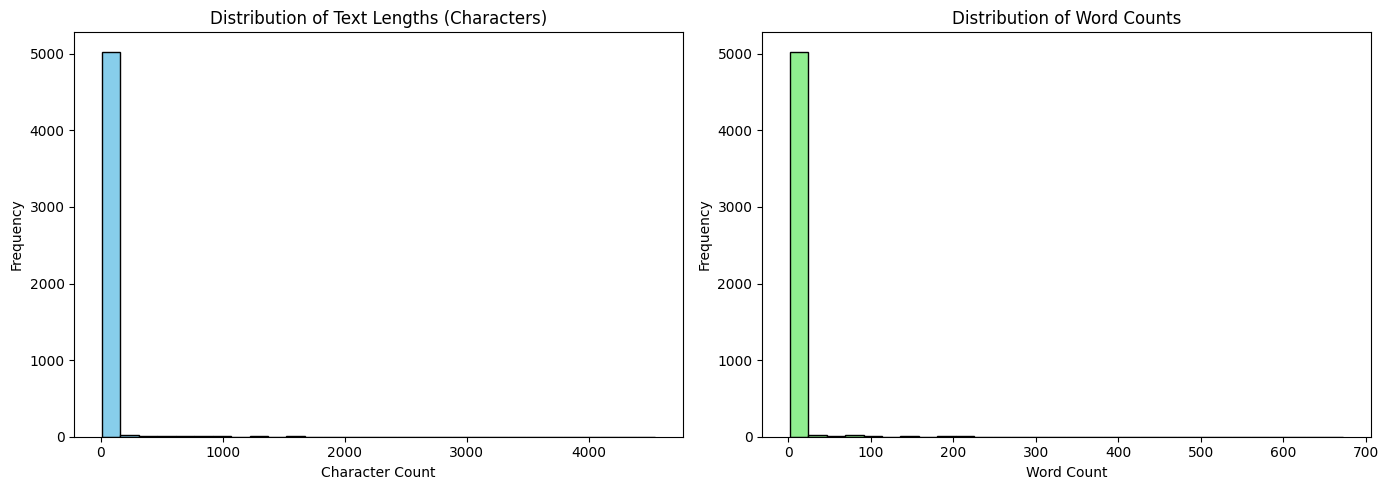


=== Source Distribution ===
source
Instagram    879
Facebook     861
Website      839
Google       828
Twitter      802
WhatsApp     791
Reddit       100
Name: count, dtype: int64


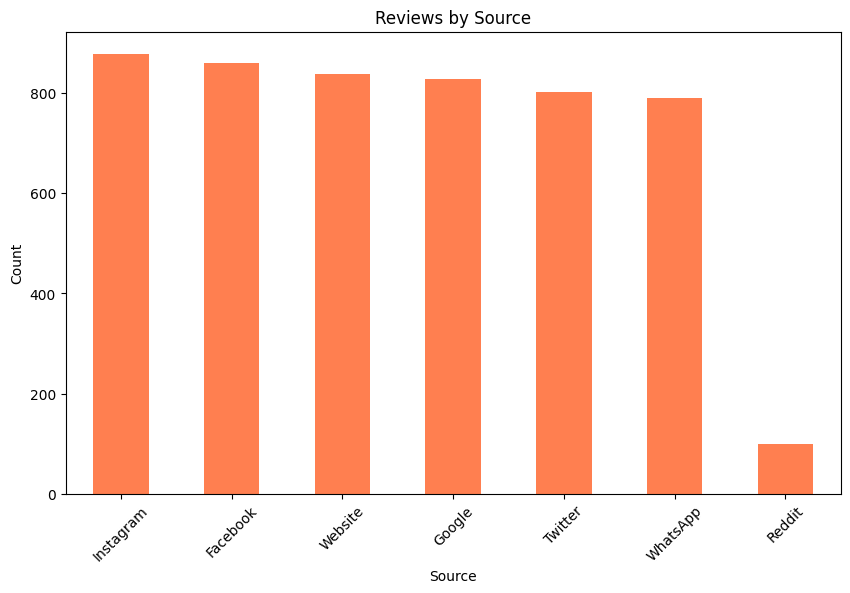

In [20]:
# Data quality checks
print("=== Data Quality Report ===")
print(f"Total reviews: {len(df_reviews)}")
print(f"Missing values: {df_reviews.isnull().sum().sum()}")
print(f"Empty cleaned texts: {(df_reviews['cleaned_text'] == '').sum()}")
print(f"\nText length statistics:")
print(df_reviews['text_length'].describe())
print(f"\nWord count statistics:")
print(df_reviews['word_count'].describe())

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_reviews['text_length'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Text Lengths (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_reviews['word_count'], bins=30, edgecolor='black', color='lightgreen')
axes[1].set_title('Distribution of Word Counts')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Source distribution
if 'source' in df_reviews.columns:
    print("\n=== Source Distribution ===")
    print(df_reviews['source'].value_counts())
    
    plt.figure(figsize=(10, 6))
    df_reviews['source'].value_counts().plot(kind='bar', color='coral')
    plt.title('Reviews by Source')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


## Step 4: Save Processed Data

Save the cleaned and processed data for use in downstream cognitive processing tasks.


In [21]:
# Save processed data
import os

# Create directories if they don't exist
os.makedirs('../../data/processed', exist_ok=True)
os.makedirs('../../data/models', exist_ok=True)

# Save processed dataframe
output_path = '../../data/processed/cleaned_reviews.csv'
df_reviews.to_csv(output_path, index=False)
print(f"✅ Processed data saved to: {output_path}")

# Save preprocessor for later use
import pickle
preprocessor_path = '../../data/models/text_preprocessor.pkl'
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f"✅ Preprocessor saved to: {preprocessor_path}")

# Display summary
print(f"\n=== Pipeline Summary ===")
print(f"Original records: {len(df_reviews)}")
print(f"Successfully processed: {(df_reviews['cleaned_text'] != '').sum()}")
print(f"Average text length: {df_reviews['text_length'].mean():.2f} characters")
print(f"Average word count: {df_reviews['word_count'].mean():.2f} words")


✅ Processed data saved to: ../../data/processed/cleaned_reviews.csv
✅ Preprocessor saved to: ../../data/models/text_preprocessor.pkl

=== Pipeline Summary ===
Original records: 5100
Successfully processed: 5100
Average text length: 63.34 characters
Average word count: 8.47 words


## Summary

This notebook has completed the data perception and preparation phase:

1. ✅ **Data Acquisition**: Loaded sample datasets (replace with actual data)
2. ✅ **Text Preprocessing**: Implemented comprehensive cleaning pipeline
3. ✅ **Data Quality Analysis**: Analyzed and visualized data characteristics
4. ✅ **Data Persistence**: Saved processed data for cognitive processing

### Next Steps:
- Load actual customer review and social media datasets
- Enhance preprocessing for Luganda language support
- Add more sophisticated cleaning for Ugandan context
- Integrate data from multiple sources
- Prepare data for sentiment analysis and topic modeling
